# 2.2 Bluesky: Textual Analysis

**Input:** `Data/1_Bronze/Bluesky/bsky_US_2024_raw.csv`


In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [138]:
os.getcwd()
os.chdir("C:\\Users\\Ddhuy\\OneDrive - UGent\\DocumentenUGentMaster\\SocialMediaAndWebAnalysis\\group-project-SMWA")

## Content

- text preprocessing
    -  posts filtered to english text only
    -  used the text_preprocessing notebook to preprocess
    -  spell check via  symspellpy to reduce sparsity of tdm matrix 

- tfidf
- svd
- wordcloud 

--> per buzzgroup: overall, trumpbuzz, harrisbuzz, electionbuzz

**Input:** `Data/1_Bronze/Bluesky/bsky_US_2024_raw.csv`


In [139]:
bluesky_df = pd.read_csv("Data\\1_Bronze\\Bluesky\\bsky_US_2024_raw.csv")

In [140]:
bluesky_df.head()

,uri,author,display,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,query,parent_uri
0,at://did:plc:taylv7omre5pg7arsuidtwg4/app.bsky...,outrowes.bsky.social,Wes,Os Swing States são os estados americanos onde...,2024-11-04T23:53:52.367Z,1,1,0,[],False,post,#USElection2024,NaN
1,at://did:plc:lpqouffbl3gbah3r23vh7odp/app.bsky...,runhudi.bsky.social,Yehuda M.,Canadian election prediction: Americans will g...,2024-11-04T23:44:15.319Z,0,0,1,[],False,post,#USElection2024,NaN
2,at://did:plc:3ixumkojw3dpsfhdyjodfxmk/app.bsky...,manabouttown.bsky.social,NaN,Why are swinger states so important in the #US...,2024-11-04T23:35:21.961Z,0,0,0,[],False,post,#USElection2024,NaN
3,at://did:plc:pebmhdoqw45rp5bpu53myfoc/app.bsky...,justdev1.bsky.social,That Dev Guy,If Joe Biden winning felt like Return of the J...,2024-11-04T23:23:51.647Z,0,0,0,[],False,post,#USElection2024,NaN
4,at://did:plc:bj6epztbrubmkloj4ethecvy/app.bsky...,alexverbeek.bsky.social,Alexander Verbeek,Will the U.S. Presidential Elections be a Turn...,2024-11-04T22:48:56.805Z,3,1,1,[],False,post,#USElection2024,NaN


In [141]:
bluesky_df.columns

Index(['uri', 'author', 'display', 'text', 'timestamp', 'likes', 'reposts',
       'replies', 'mentions', 'is_reply', 'post_type', 'query', 'parent_uri'],
      dtype='object')

In [142]:
# Keep core columns
df = bluesky_df[['text', 'timestamp', 'likes', 'reposts', 'replies', 'mentions', 'is_reply', 'post_type']].copy()

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)

df = df.dropna(subset=['timestamp']).copy()

# Date/time features

ts = df['timestamp']
df['date'] = ts.dt.date
df['hour'] = ts.dt.hour
df['weekday'] = ts.dt.day_name()

print('rows', len(df), 'from', df['timestamp'].min(), 'to', df['timestamp'].max())
print('Distinct dates', df['date'].nunique())

rows 32159 from 2024-07-05 03:04:25.279000+00:00 to 2026-01-19 01:45:26.080000+00:00
Distinct dates 188


In [143]:
df.dtypes

text                      object
timestamp    datetime64[ns, UTC]
likes                      int64
reposts                    int64
replies                    int64
mentions                  object
is_reply                    bool
post_type                 object
date                      object
hour                       int32
weekday                   object
dtype: object

In [144]:
df['date'] = pd.to_datetime(df['date'])

In [145]:
df.head(1)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,date,hour,weekday
0,Os Swing States são os estados americanos onde...,2024-11-04 23:53:52.367000+00:00,1,1,0,[],False,post,2024-11-04,23,Monday


In [146]:
df['text'].str.contains('#USElection2024').value_counts()

text
False    31794
True       365
Name: count, dtype: int64

In [147]:
df['text'] = df['text'].str.replace('#USElection2024', '', regex=True)
df['text'].str.contains('#USElection2024').value_counts()

text
False    32159
Name: count, dtype: int64

In [148]:
from langdetect import detect, LangDetectException

def detect_language(text):
    if not isinstance(text, str) or not text.strip():
        return None
    try:
        return detect(text)
    except LangDetectException:
        return None

df['detected_lang'] = df['text'].astype(str).apply(detect_language)

df_en = df[df['detected_lang'] == 'en'].copy()

print("Total rows:", len(df))
print("English rows:", len(df_en))
print(df_en['detected_lang'].value_counts())

Total rows: 32159
English rows: 26370
detected_lang
en    26370
Name: count, dtype: int64


### Analyzing review length distribution 

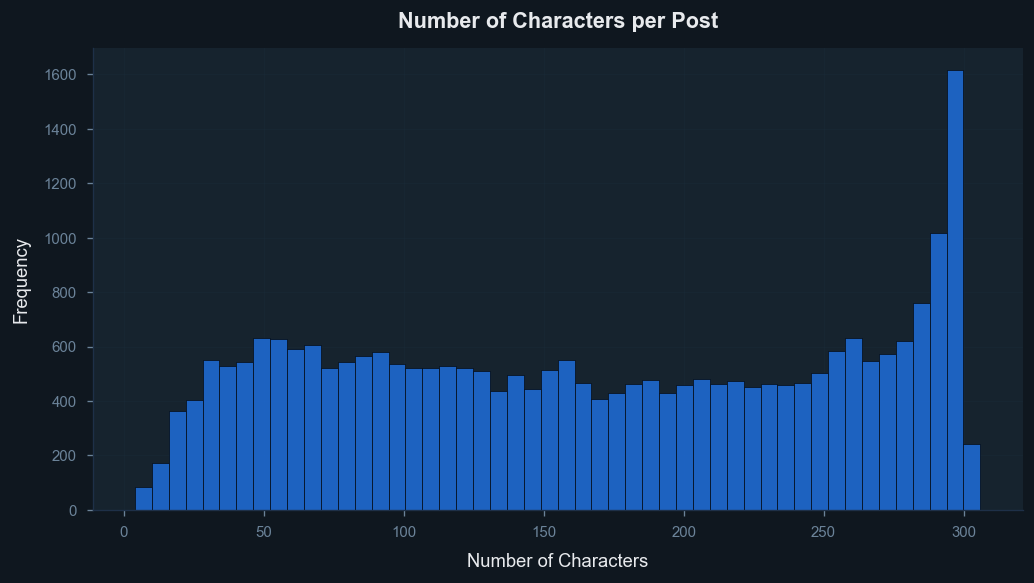

Average characters per post: 166.7
Median characters per post: 165.0


In [149]:
# Calculate character count for each review
char_counts = df_en['text'].str.len()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(char_counts, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.title('Number of Characters per Post')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average characters per post: {char_counts.mean():.1f}")
print(f"Median characters per post: {char_counts.median():.1f}")

### Word count distribution

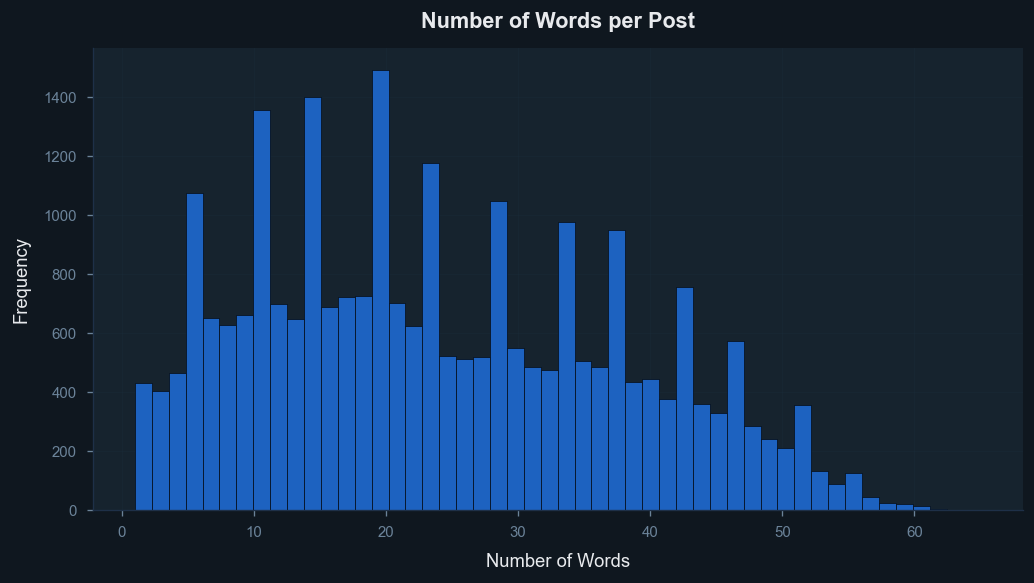

Average words per post: 24.1
Median words per post: 22.0


In [150]:
# Calculate word count for each review
word_counts = df_en['text'].str.split().str.len()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(word_counts, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Number of Words per Post')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average words per post: {word_counts.mean():.1f}")
print(f"Median words per post: {word_counts.median():.1f}")

### Text preprocessing

#### test preprocessing function first

In [151]:
import importlib.util
import sys

# Load directly from the full path
spec = importlib.util.spec_from_file_location(
    "text_preprocessing",
    r"C:\Users\Ddhuy\OneDrive - UGent\DocumentenUGentMaster\SocialMediaAndWebAnalysis\group-project-SMWA\Functions\text_preprocessing.py"
)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

# Now use the functions
clean_text = module.clean_text
apply_text_cleaning = module.apply_text_cleaning

# Test
test = "Harris speech apple.news/AASCFgwiDS_q... #Trump look small"
print(clean_text(test))

harris speech trump look small


In [152]:
test_cases = [
    ("URL fragment",   "Harris speech apple.news/AASCFgwiDS_q..."),
    ("Full URL",       "Check this https://t.co/abc123xyz out"),
    ("Hashtag",        "#Election2024 is today"),
    ("Mention",        "Hey @realDonaldTrump what do you think"),
    ("Normal text",    "Harris gave a great speech about democracy"),
    ("Mixed",          "Harris speech apple.news/AASCFgwiDS_q... #Trump @user https://t.co/xyz"),
]

for label, text in test_cases:
    result = clean_text(text)
    print(f"  {label:15} | IN:  {text}")
    print(f"               | OUT: {result}")
    print()

  URL fragment    | IN:  Harris speech apple.news/AASCFgwiDS_q...
               | OUT: harris speech

  Full URL        | IN:  Check this https://t.co/abc123xyz out
               | OUT: check

  Hashtag         | IN:  #Election2024 is today
               | OUT: election today

  Mention         | IN:  Hey @realDonaldTrump what do you think
               | OUT: hey think

  Normal text     | IN:  Harris gave a great speech about democracy
               | OUT: harris gave great speech democracy

  Mixed           | IN:  Harris speech apple.news/AASCFgwiDS_q... #Trump @user https://t.co/xyz
               | OUT: harris speech trump



end test preprocessing function

#### Preprocessing

In [153]:
SOCIAL_STOPS = {             
}

df_clean = apply_text_cleaning(
    df_en,
    text_col='text',
    output_col='text_clean',
    extra_stopwords=SOCIAL_STOPS,
    verbose=True
)

✓ Cleaned 'text' → 'text_clean'
  Rows       : 26,370
  Avg words  : 14.4
  Empty texts: 118

                                          text_clean  word_count
0  canadian election prediction americans polls d...          23
1    swinger states important really many sex people           7
2  joe biden winning felt like return jedi end el...          15


In [154]:
import re

def unique_word_count(texts):
    """Count unique words across all documents."""
    if isinstance(texts, pd.Series):
        texts = texts.tolist()
    elif isinstance(texts, str):
        texts = [texts]
    
    unique_words = set()
    for text in texts:
        words = text.split()
        unique_words.update(words)
    
    return len(unique_words)

# Baseline: count unique words in original reviews before any preprocessing
baseline_count = unique_word_count(df_en['text'])
print(f"✓ Baseline unique words: {baseline_count:,}")
print(f"\nThis represents the vocabulary size before preprocessing.")

✓ Baseline unique words: 83,867

This represents the vocabulary size before preprocessing.


In [155]:
final_count = unique_word_count(df_clean['text_clean'])

print(f"  Total reduction: {baseline_count - final_count:,} words")
print(f"  Final vocabulary: {final_count:,} unique words")
print(f"  Original vocabulary: {baseline_count:,} unique words")

  Total reduction: 54,281 words
  Final vocabulary: 29,586 unique words
  Original vocabulary: 83,867 unique words


### Before vs. after comparison

In [156]:
# Compare example review before and after preprocessing
idx = 20

print("="*80)
print("BEFORE PREPROCESSING:")
print("="*80)
print(df_en['text'].iloc[idx][:200])

print("="*80)
print("AFTER PREPROCESSING:")
print("="*80)
print(df_clean['text_clean'].iloc[idx][:200])

BEFORE PREPROCESSING:
Join us for our  debrief on Friday! Get first-hand insights into the US election outcome, where we seek to understand what the results mean for a progressive transatlantic policy agenda. W/ @metinhakv
AFTER PREPROCESSING:
join debrief friday get first hand insights election outcome seek understand results mean progressive transatlantic policy agenda bsky social leslie herod scott holcomb chair maria skora register


In [157]:
start_date = '2024-07-05'
end_date = '2024-11-05'

mask = (df_clean['date'] >= start_date) & (df_clean['date'] <= end_date)
df_clean = df_clean.loc[mask]

# 4. Optional: Reset the index so it starts from 0 again
df_clean = df_clean.reset_index(drop=True)

# 5. Check the result
print(f"Number of rows after filtering: {len(df_clean)}")
print(f"Date range: {df_clean['date'].min()} to {df_clean['date'].max()}")

Number of rows after filtering: 26256
Date range: 2024-07-05 00:00:00 to 2024-11-05 00:00:00


In [158]:
df_clean.head(1)

,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,date,hour,weekday,detected_lang,text_clean,words,word_count
0,Canadian election prediction: Americans will g...,2024-11-04 23:44:15.319000+00:00,0,0,1,[],False,post,2024-11-04,23,Monday,en,canadian election prediction americans polls d...,"[canadian, election, prediction, americans, po...",23


### Creating the document-term matrix with tf-idf

In [159]:
import re
from symspellpy import SymSpell, Verbosity
import pkg_resources

# ── 1. Repeated character normalizer ─────────────────────────────────────────
def normalize_repeated_chars(text: str, max_repeat: int = 2) -> str:
    if not isinstance(text, str):
        return text
    return re.sub(r'(.)\1{' + str(max_repeat) + r',}', r'\1' * max_repeat, text)

# ── 2. Load SymSpell dictionary once ─────────────────────────────────────────
sym_spell = SymSpell(max_dictionary_edit_distance=2)
dict_path = pkg_resources.resource_filename("symspellpy", "frequency_dictionary_en_82_765.txt")
sym_spell.load_dictionary(dict_path, term_index=0, count_index=1)

# ── 3. Protected political/social media terms ─────────────────────────────────
PROTECTED = {'trump', 'harris', 'biden', 'maga', 'gop', 'lol',
             'omg', 'tbh', 'ngl', 'imo', 'woke', 'kamala'}

# ── 4. Safe spell corrector ───────────────────────────────────────────────────
def safe_correct(text: str) -> str:
    words = text.split()
    corrected = []
    for word in words:
        if word.lower() in PROTECTED:
            corrected.append(word)
        else:
            suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
            corrected.append(suggestions[0].term if suggestions else word)
    return ' '.join(corrected)

# ── 5. Apply pipeline ─────────────────────────────────────────────────────────
df_clean['text_norm'] = (
    df_clean['text_clean']
    .apply(normalize_repeated_chars)
    .apply(safe_correct)
)

print(df_clean[['text_clean', 'text_norm']].head(5))

                                          text_clean  \
0  canadian election prediction americans polls d...   
1    swinger states important really many sex people   
2  joe biden winning felt like return jedi end el...   
3  presidential elections turning point history t...   
4  dear american voters foreigner living finland ...   

                                           text_norm  
0  canadian election prediction americans polls d...  
1    swinger states important really many sex people  
2  joe biden winning felt like return jedi end el...  
3  presidential elections turning point history t...  
4  dear american voters foreigner living finland ...  


In [161]:
# df_clean.to_csv("Data/2_Silver/Bluesky/cleaned_data.csv", index=False)
# print(f"✓ Saved {len(df_clean):,} rows")

In [162]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ── 1. Build TF-IDF vectorizer (following lecture parameters) ──
vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',  # Words with at least 2 characters (lecture default)
    lowercase=False,               # Already preprocessed
    max_features=None              # Keep all terms initially (lecture approach)
)

tfidf_matrix = vectorizer.fit_transform(df_clean['text_clean'])
feature_names = vectorizer.get_feature_names_out()

print(f"DTM shape: {tfidf_matrix.shape}")
print(f"Documents : {tfidf_matrix.shape[0]}")
print(f"Terms     : {tfidf_matrix.shape[1]}")
sparsity = (1.0 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100
print(f"Sparsity  : {sparsity:.1f}%")

# ── 2. Inspect a sample (first 5 docs × first 10 terms) ──
dtm_df = pd.DataFrame(
    tfidf_matrix[:5, :10].toarray(),
    columns=feature_names[:10],
    index=[f'Doc {i+1}' for i in range(5)]
)
print("\nSample TF-IDF Matrix:")
print(dtm_df)

DTM shape: (26256, 29523)
Documents : 26256
Terms     : 29523
Sparsity  : 100.0%

Sample TF-IDF Matrix:
       aaa  aaaaaagh  aaaaand  aaand  aace  aai  aaliyah  aand  aapi  aaraf
Doc 1  0.0       0.0      0.0    0.0   0.0  0.0      0.0   0.0   0.0    0.0
Doc 2  0.0       0.0      0.0    0.0   0.0  0.0      0.0   0.0   0.0    0.0
Doc 3  0.0       0.0      0.0    0.0   0.0  0.0      0.0   0.0   0.0    0.0
Doc 4  0.0       0.0      0.0    0.0   0.0  0.0      0.0   0.0   0.0    0.0
Doc 5  0.0       0.0      0.0    0.0   0.0  0.0      0.0   0.0   0.0    0.0


sparsity in tf-idf matrix fixed via simple spell checking (this to filter out words like 'aaaand' to 'and' for example)

In [165]:
vectorizer = TfidfVectorizer(
    token_pattern=r'\b\w{2,}\b',  # Words with at least 2 characters (lecture default)
    lowercase=False,               # Already preprocessed
    max_features=None              # Keep all terms initially (lecture approach)
)

tfidf_matrix_2 = vectorizer.fit_transform(df_clean['text_norm'])
feature_names_2 = vectorizer.get_feature_names_out()

print(f"DTM shape: {tfidf_matrix_2.shape}")
print(f"Documents : {tfidf_matrix_2.shape[0]}")
print(f"Terms     : {tfidf_matrix_2.shape[1]}")
sparsity = (1.0 - tfidf_matrix_2.nnz / (tfidf_matrix_2.shape[0] * tfidf_matrix_2.shape[1])) * 100
print(f"Sparsity  : {sparsity:.1f}%")

# ── 2. Inspect a sample (first 5 docs × first 10 terms) ──
dtm_df = pd.DataFrame(
    tfidf_matrix_2[:5, :10].toarray(),
    columns=feature_names_2[:10],
    index=[f'Doc {i+1}' for i in range(5)]
)
print("\nSample TF-IDF Matrix:")
print(dtm_df)

DTM shape: (26256, 26206)
Documents : 26256
Terms     : 26206
Sparsity  : 99.9%

Sample TF-IDF Matrix:
       aachen  aah  aaliyah  aarau  aaron  aarongouveia  aaronrupar  \
Doc 1     0.0  0.0      0.0    0.0    0.0           0.0         0.0   
Doc 2     0.0  0.0      0.0    0.0    0.0           0.0         0.0   
Doc 3     0.0  0.0      0.0    0.0    0.0           0.0         0.0   
Doc 4     0.0  0.0      0.0    0.0    0.0           0.0         0.0   
Doc 5     0.0  0.0      0.0    0.0    0.0           0.0         0.0   

       aaronsmith  aba  abalone  
Doc 1         0.0  0.0      0.0  
Doc 2         0.0  0.0      0.0  
Doc 3         0.0  0.0      0.0  
Doc 4         0.0  0.0      0.0  
Doc 5         0.0  0.0      0.0  


inspect different tfidf values

In [168]:
print(df_clean['post_type'].value_counts())

post_type
post     20725
reply     5531
Name: count, dtype: int64


In [169]:
for group in df_clean['post_type'].unique():
    mask = (df_clean['post_type'] == group).values
    mean_scores = tfidf_matrix_2[mask].mean(axis=0).A1
    top_idx = mean_scores.argsort()[::-1][:15]
    print(f"\n{group} — top 15 distinctive words:")
    print(', '.join(feature_names_2[top_idx]))


post — top 15 distinctive words:
trump, election, debate, maga, republicans, democrats, harris, politics, vote, dec, gop, kamalaharris, donaldtrump, harriswalz, house

reply — top 15 distinctive words:
trump, good, like, people, one, get, would, right, know, think, see, even, really, yes, well


In [170]:
def assign_buzz(text):
    text = str(text).lower()
    if 'trump' in text:
        return 'TrumpBuzz'
    elif 'harris' in text:
        return 'HarrisBuzz'
    else:
        return 'ElectionBuzz'

df_clean['buzz_group'] = df_clean['text'].str.lower().apply(assign_buzz)
print(df_clean['buzz_group'].value_counts())

buzz_group
ElectionBuzz    12677
TrumpBuzz       10716
HarrisBuzz       2863
Name: count, dtype: int64


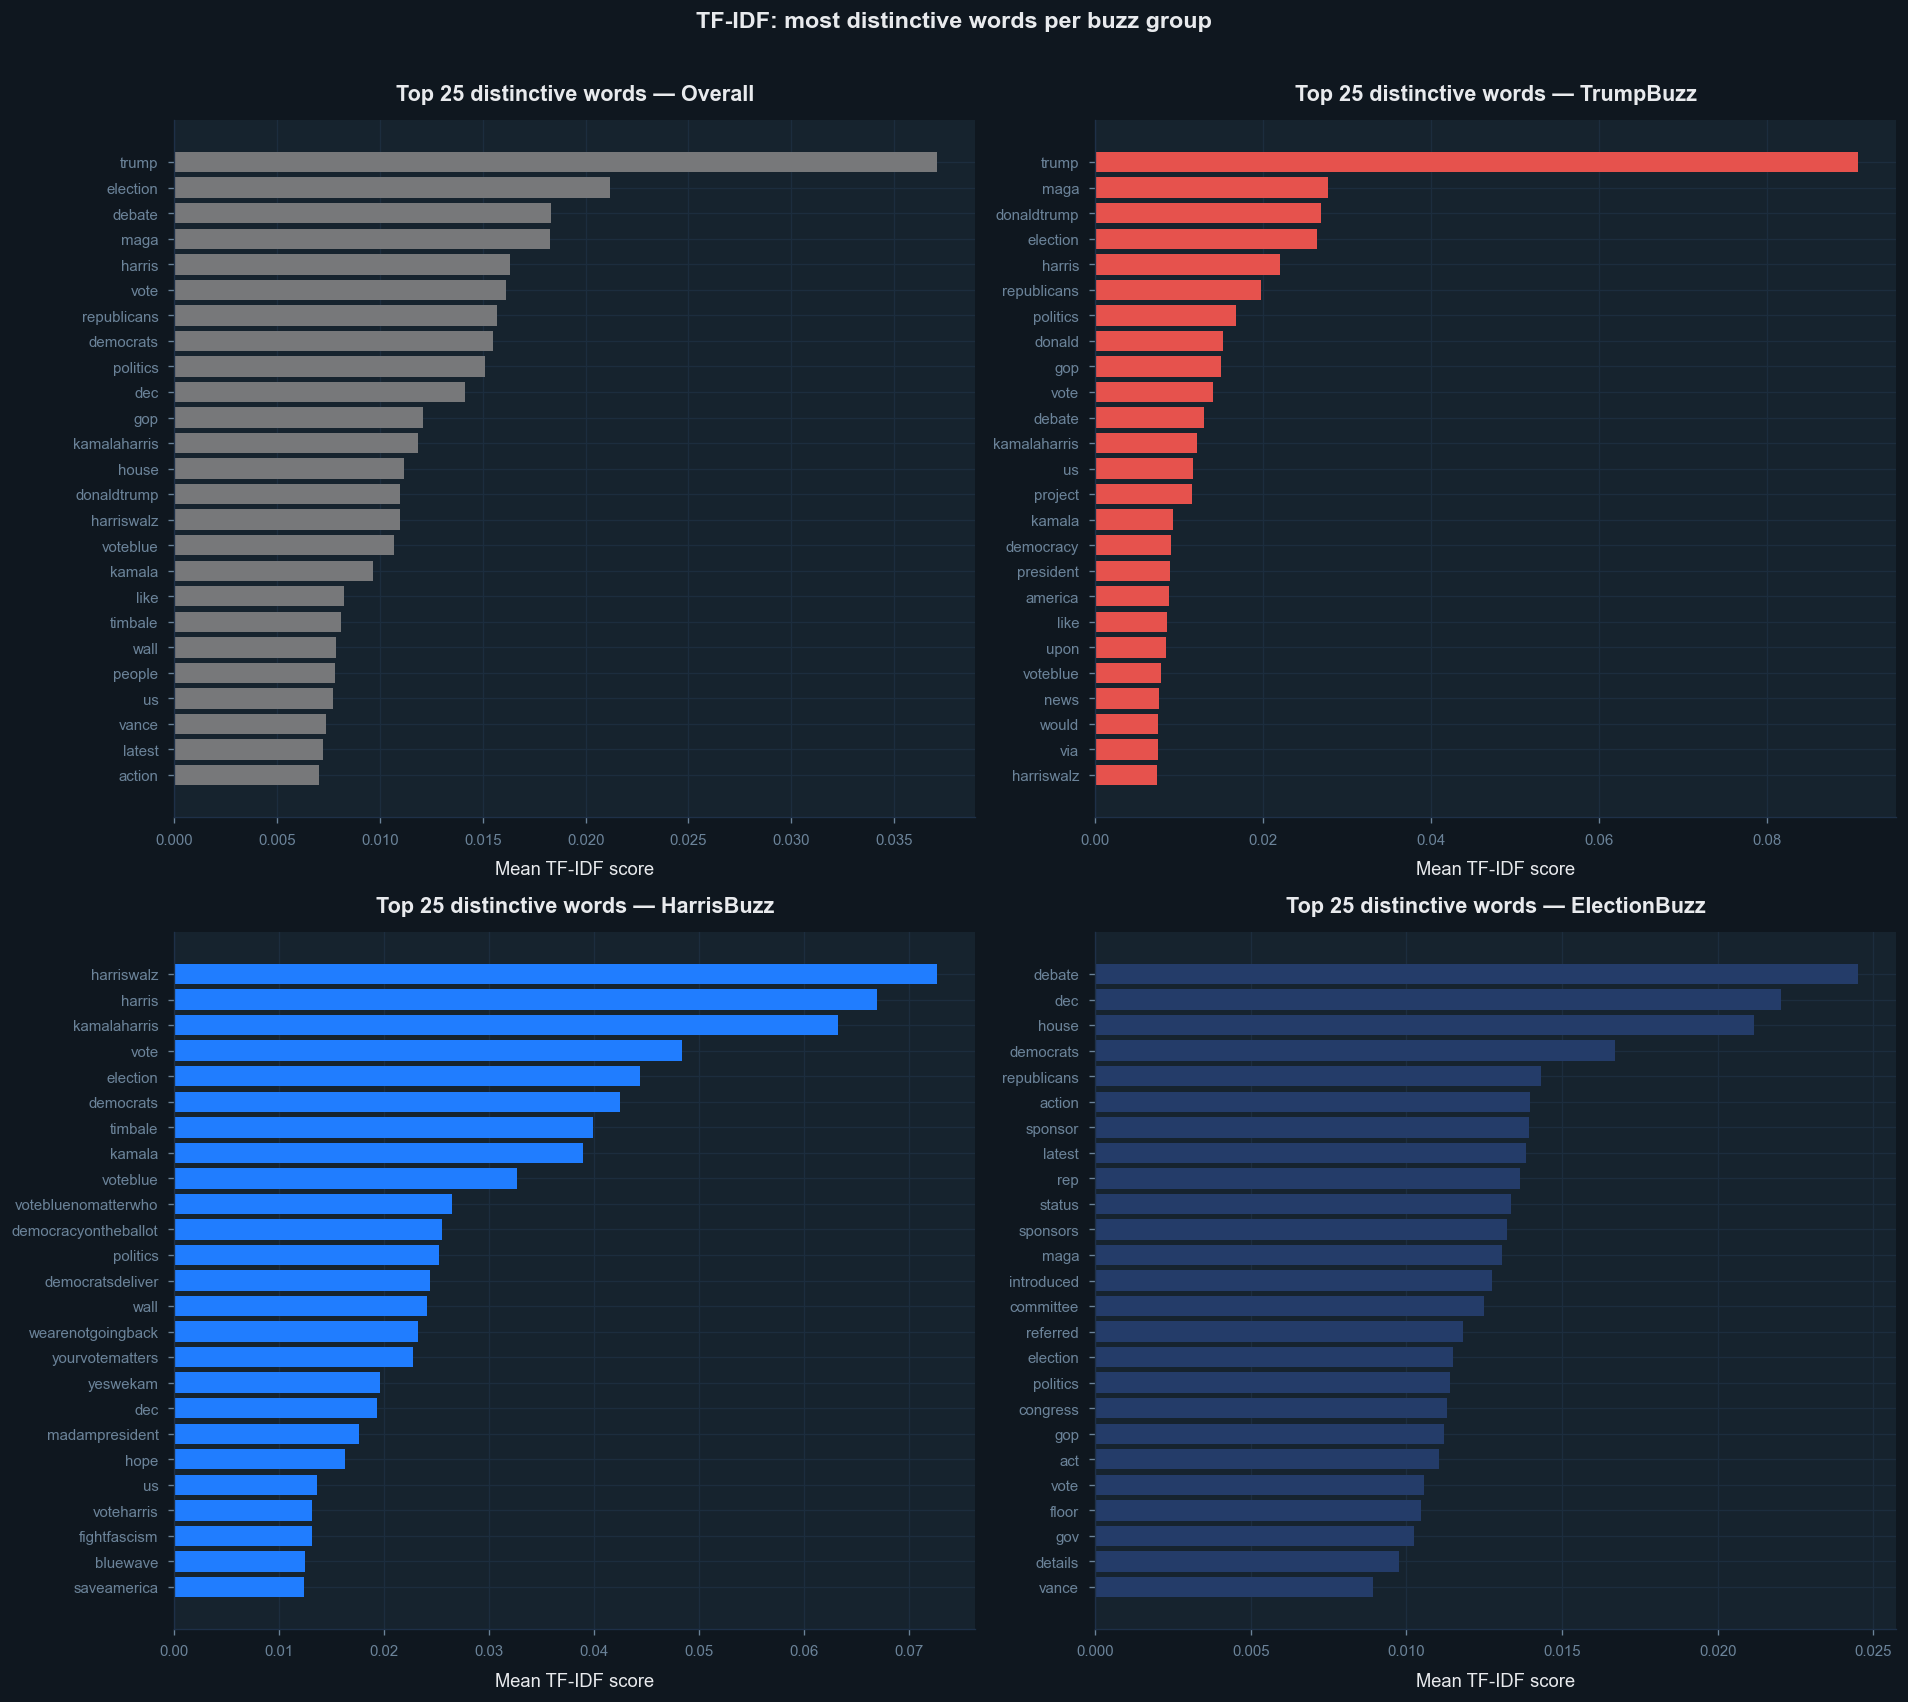

In [173]:
GROUPS     = ['Overall', 'TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']
colors_bar = {
    'Overall':      NEUTRAL,
    'TrumpBuzz':    REPUBLICAN,
    'HarrisBuzz':   DEMOCRAT,
    'ElectionBuzz': ACCENT,
}

n_rows = tfidf_matrix_2.shape[0]  # derive from the new matrix

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.patch.set_facecolor(BG_DARK)

for ax, group in zip(axes.flat, GROUPS):
    mask = (np.ones(n_rows, dtype=bool) if group == 'Overall'
            else (df_clean['buzz_group'] == group).values)

    mean_scores = tfidf_matrix_2[mask].mean(axis=0).A1
    top_idx     = mean_scores.argsort()[::-1][:25]

    ax.barh(feature_names_2[top_idx][::-1], mean_scores[top_idx][::-1], color=colors_bar[group])
    ax.set_facecolor(BG_PANEL)
    ax.set_title(f'Top 25 distinctive words — {group}',
                 color=TEXT_PRIMARY, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF score', color=TEXT_PRIMARY)
    ax.tick_params(colors=TEXT_MUTED)

plt.suptitle('TF-IDF: most distinctive words per buzz group',
             fontsize=14, color=TEXT_PRIMARY, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### SVD

In [174]:
from sklearn.decomposition import TruncatedSVD

# Start with maximum possible components
# For TruncatedSVD: n_components < min(n_samples, n_features)
n_docs = tfidf_matrix_2.shape[0]
n_terms = tfidf_matrix_2.shape[1]
max_components = min(n_docs, n_terms) - 1

print(f"Original matrix shape: {tfidf_matrix_2.shape}")
print(f"Maximum components: {max_components}")

# Apply TruncatedSVD with all possible components
svd_full = TruncatedSVD(n_components=min(100, max_components), random_state=42)
documents_concepts_full = svd_full.fit_transform(tfidf_matrix_2)

print(f"\nReduced matrix shape: {documents_concepts_full.shape}")
print(f"Dimensionality reduction: {n_terms} → {documents_concepts_full.shape[1]}")

Original matrix shape: (26256, 26206)
Maximum components: 26205

Reduced matrix shape: (26256, 100)
Dimensionality reduction: 26206 → 100


In [175]:
# 1. U matrix (document-by-concept): returned by transform()
print("1. Document-by-Concept Matrix (U):")
print(f"   Shape: {documents_concepts_full.shape}")
print(f"   This is what we use as features for machine learning!")
print(f"\n   First 5 documents, first 5 concepts:")
print(documents_concepts_full[:5, :5])

# 2. Sigma (Σ): singular values (strength of each concept)
print("\n2. Singular Values (Σ - diagonal of sigma matrix):")
print(f"   Shape: {svd_full.singular_values_.shape}")
print(f"   First 10 values: {svd_full.singular_values_[:10]}")

# 3. V^T matrix (concept-by-term): components_
print("\n3. Concept-by-Term Matrix (V^T):")
print(f"   Shape: {svd_full.components_.shape}")
print(f"   Shows how terms contribute to each concept")

1. Document-by-Concept Matrix (U):
   Shape: (26256, 100)
   This is what we use as features for machine learning!

   First 5 documents, first 5 concepts:
[[ 3.41090508e-02  7.91070554e-02  3.31186744e-02  3.83238193e-02
  -3.86636731e-02]
 [ 1.81585283e-02  2.43025890e-02  3.38520246e-02 -2.73953014e-02
   8.90502365e-03]
 [ 3.69339392e-02  7.20738451e-02  4.09427397e-02  2.36153238e-02
   3.31644918e-02]
 [ 1.26927833e-02  2.73691669e-02  3.42787653e-02 -9.88090247e-03
  -2.71061814e-05]
 [ 6.20324999e-02  1.24558319e-01  7.05327820e-02  3.07662767e-02
   6.91201415e-02]]

2. Singular Values (Σ - diagonal of sigma matrix):
   Shape: (100,)
   First 10 values: [20.21622809 18.75052897 15.01071829 12.40665389 11.44130004 10.88116198
 10.40086713 10.33714648  9.51526918  9.37885823]

3. Concept-by-Term Matrix (V^T):
   Shape: (100, 26206)
   Shows how terms contribute to each concept


#### Interpreting Latent Concepts

Each component represents a latent semantic concept. Let's examine which terms are most strongly associated with the first few concepts:

In [176]:
def display_top_terms_per_concept(svd_model, feature_names, n_top=10, n_concepts=5):
    """Display top terms for each latent concept."""
    for i in range(min(n_concepts, svd_model.n_components)):
        # Get component weights for all terms
        component = svd_model.components_[i]
        
        # Get indices of top terms (by absolute value)
        top_indices = np.argsort(np.abs(component))[::-1][:n_top]
        top_terms = [feature_names[idx] for idx in top_indices]
        top_weights = [component[idx] for idx in top_indices]
        
        print(f"\nConcept {i+1} (σ = {svd_full.singular_values_[i]:.3f}):")
        for term, weight in zip(top_terms, top_weights):
            print(f"  {term:20s} {weight:>8.4f}")

display_top_terms_per_concept(svd_full, feature_names, n_top=10, n_concepts=2)


Concept 1 (σ = 20.216):
  gradual                0.3679
  residence              0.2379
  acknowledge            0.2354
  residentevil           0.2351
  rewires                0.2345
  inhomecare             0.2339
  herstory               0.2303
  clackamascountyrepublicans   0.2271
  perimeter              0.2184
  passauer               0.2170

Concept 2 (σ = 18.751):
  dncinchi               0.3427
  supplier               0.2852
  smoke                  0.2788
  negative               0.2064
  supportdonaldtrump     0.1961
  ifb                    0.1880
  gatherings             0.1788
  garza                  0.1774
  gradual               -0.1668
  suppressor             0.1528


#### Explained Variance

The singular values tell us how much variance each component captures. We can use this to decide how many components to keep:

In [177]:
# Calculate variance explained by each component
# Variance is proportional to squared singular values
variance = svd_full.singular_values_ ** 2

# Calculate percentage of variance explained
total_variance = np.sum(variance)
explained_variance_ratio = variance / total_variance

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Variance Explained:")
print(f"{'Component':<12} {'Variance':<12} {'% Explained':<15} {'Cumulative %':<15}")
print("-" * 60)
for i in range(min(10, len(explained_variance_ratio))):
    print(f"{i+1:<12} {variance[i]:<12.4f} {explained_variance_ratio[i]*100:<15.2f} {cumulative_variance[i]*100:<15.2f}")

print(f"\nFirst 3 components explain {cumulative_variance[2]*100:.1f}% of variance")
print(f"First 5 components explain {cumulative_variance[4]*100:.1f}% of variance")

Variance Explained:
Component    Variance     % Explained     Cumulative %   
------------------------------------------------------------
1            408.6959     8.28            8.28           
2            351.5823     7.12            15.40          
3            225.3217     4.56            19.96          
4            153.9251     3.12            23.08          
5            130.9033     2.65            25.73          
6            118.3997     2.40            28.12          
7            108.1780     2.19            30.31          
8            106.8566     2.16            32.48          
9            90.5403      1.83            34.31          
10           87.9630      1.78            36.09          

First 3 components explain 20.0% of variance
First 5 components explain 25.7% of variance


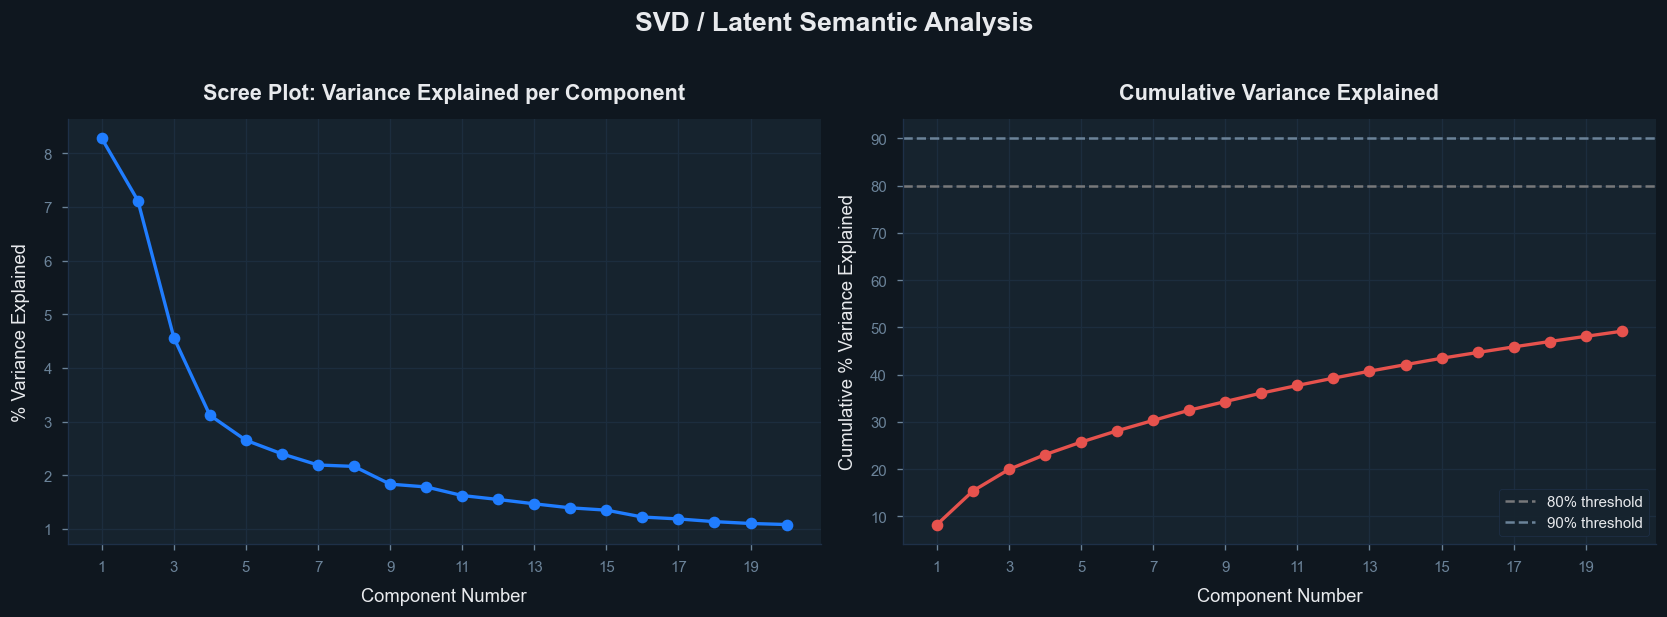

80% variance explained with 61 components
90% variance explained with 79 components
95% variance explained with 89 components


In [178]:
from house_style import *
apply_style()

n_components_to_plot = min(20, len(explained_variance_ratio))
x = range(1, n_components_to_plot + 1)

fig, axes = styled_fig(1, 2, figsize=(14, 5), title="SVD / Latent Semantic Analysis")

# Plot 1: Variance per component 
axes[0].plot(x, explained_variance_ratio[:n_components_to_plot] * 100,
             color=DEMOCRAT, linewidth=2, marker='o', markersize=6)
axes[0].set_xlabel('Component Number')
axes[0].set_ylabel('% Variance Explained')
axes[0].set_title('Scree Plot: Variance Explained per Component')
axes[0].set_xticks(range(1, n_components_to_plot + 1, 2))

# Plot 2: Cumulative variance 
axes[1].plot(x, cumulative_variance[:n_components_to_plot] * 100,
             color=REPUBLICAN, linewidth=2, marker='o', markersize=6)
axes[1].axhline(80, color=NEUTRAL,   linestyle='--', linewidth=1.5, label='80% threshold')
axes[1].axhline(90, color=TEXT_MUTED, linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].set_xlabel('Component Number')
axes[1].set_ylabel('Cumulative % Variance Explained')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, n_components_to_plot + 1, 2))
axes[1].legend()

plt.tight_layout()
plt.show()

# Thresholds 
for threshold in [0.80, 0.90, 0.95]:
    n_comp = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained with {n_comp} components")

In [183]:
n_components_optimal = np.argmax(cumulative_variance >= 0.80) + 1

print(f"Using {n_components_optimal} components (explains {cumulative_variance[n_components_optimal-1]*100:.1f}% of variance)")

lsa = TruncatedSVD(n_components=n_components_optimal, random_state=42)
documents_lsa = lsa.fit_transform(tfidf_matrix_2)  # ← was tfidf_matrix

print(f"\nOriginal dimensionality: {tfidf_matrix_2.shape[1]} terms")
print(f"Reduced dimensionality: {documents_lsa.shape[1]} concepts")
print(f"Dimensionality reduction: {(1 - documents_lsa.shape[1]/tfidf_matrix_2.shape[1])*100:.1f}%")

Using 61 components (explains 80.3% of variance)

Original dimensionality: 26206 terms
Reduced dimensionality: 61 concepts
Dimensionality reduction: 99.8%


In [180]:
documents_lsa.shape

(26256, 61)

In [181]:
df_clean.shape

(26256, 17)

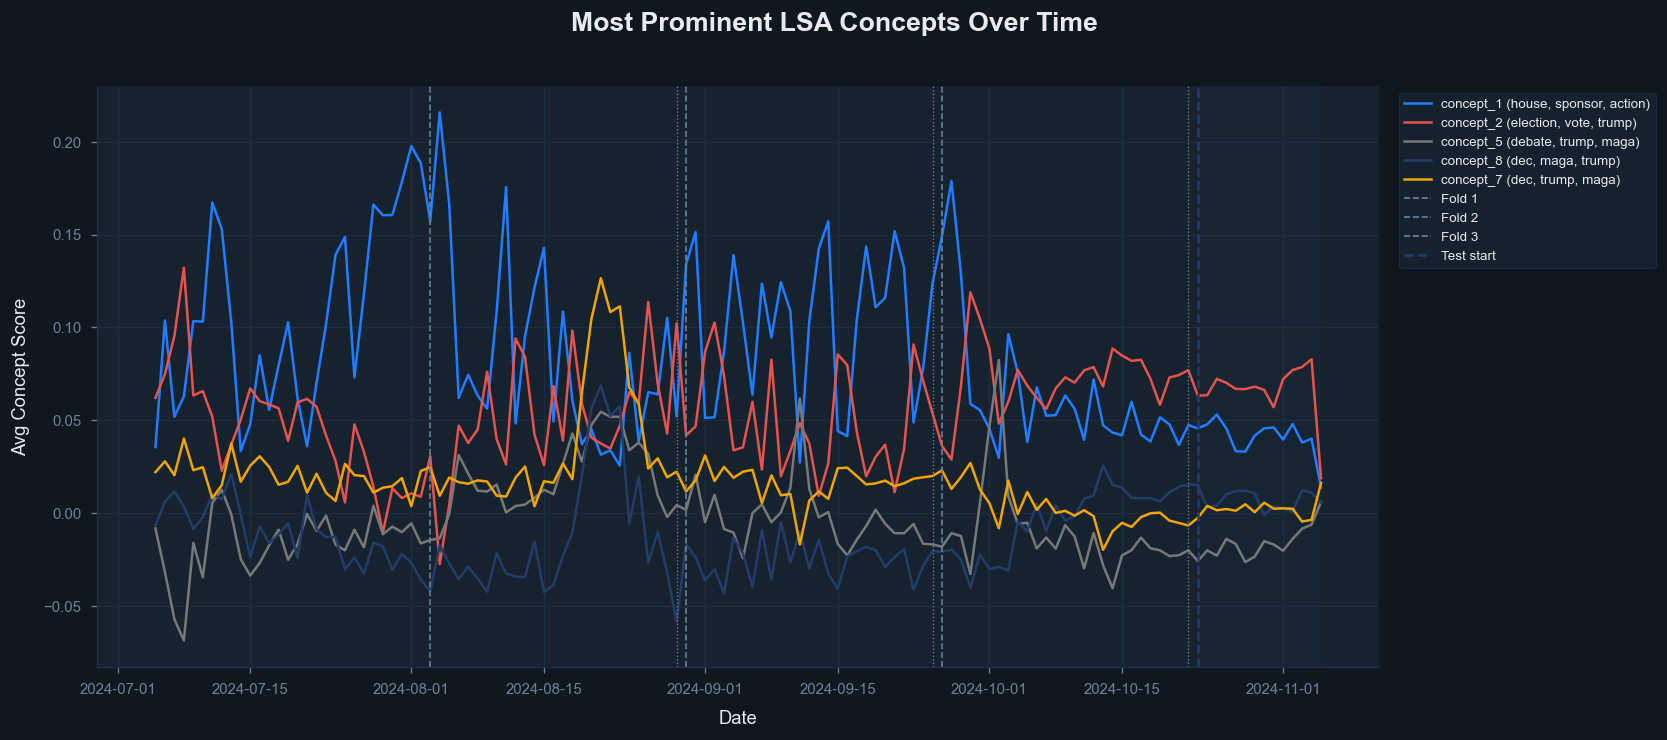

In [184]:
from house_style import *
from Functions.data_splits import get_cv_folds, get_test_split
apply_style()

# ── Add date back ─────────────────────────────────────────────────────────────
lsa_cols = [f'concept_{i+1}' for i in range(n_components_optimal)]
lsa_df   = pd.DataFrame(documents_lsa, columns=lsa_cols, index=df_clean.index)
lsa_df['date'] = df_clean['date'].values

# ── Daily average per concept ─────────────────────────────────────────────────
daily_concepts = lsa_df.groupby('date')[lsa_cols].mean()
top_concepts   = daily_concepts.var().nlargest(5).index.tolist()

# ── Get fold boundaries ───────────────────────────────────────────────────────
folds            = get_cv_folds(daily_concepts.reset_index(), n_splits=3, gap=1, test_days=14)
tv_idx, test_idx = get_test_split(daily_concepts.reset_index(), test_days=14)

dates            = daily_concepts.index
test_start       = dates[tv_idx[-1] + 1]
fold_val_starts, fold_val_ends = [], []
for train_idx, val_idx in folds:
    fold_val_starts.append(dates[val_idx[0]])
    fold_val_ends.append(dates[val_idx[-1]])

# ── Single plot ───────────────────────────────────────────────────────────────
concept_colors = [DEMOCRAT, REPUBLICAN, NEUTRAL, ACCENT, "#f0a500"]

fig, ax = styled_fig(figsize=(14, 6),
                     title='Most Prominent LSA Concepts Over Time')

for concept, color in zip(top_concepts, concept_colors):
    idx       = int(concept.split('_')[1]) - 1
    component = lsa.components_[idx]
    top_terms = [vectorizer.get_feature_names_out()[i]
                 for i in np.argsort(np.abs(component))[::-1][:3]]
    label = f"{concept} ({', '.join(top_terms)})"
    ax.plot(daily_concepts.index, daily_concepts[concept],
            color=color, linewidth=1.5, label=label)

# ── Fold boundaries ───────────────────────────────────────────────────────────
for i, (val_start, val_end) in enumerate(zip(fold_val_starts, fold_val_ends), 1):
    ax.axvline(val_start, color=TEXT_MUTED, linestyle='--', linewidth=1,
               label=f'Fold {i}' if i == 1 else f'Fold {i}')
    ax.axvline(val_end,   color=TEXT_MUTED, linestyle=':',  linewidth=0.8)

# ── Test boundary ─────────────────────────────────────────────────────────────
ax.axvline(test_start, color=ACCENT, linestyle='--', linewidth=1.5, label='Test start')
ax.axvspan(test_start, dates[-1],    alpha=0.08,     color=ACCENT)

ax.set_xlabel('Date')
ax.set_ylabel('Avg Concept Score')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [185]:
for concept in top_concepts:
    idx       = int(concept.split('_')[1]) - 1
    component = lsa.components_[idx]
    top_terms = vectorizer.get_feature_names_out()[np.argsort(component)[::-1][:10]]
    print(f"{concept}: {', '.join(top_terms)}")

concept_1: house, sponsor, action, sponsors, status, latest, introduced, committee, rep, referred
concept_2: election, vote, trump, politics, voteblue, kamalaharris, harriswalz, harris, votebluenomatterwho, democracyontheballot
concept_5: debate, politics, dec, wall, harris, timbale, kamalaharris, kamala, election, donate
concept_8: dec, trump, postelection, memories, defenddemocracy, saveamerica, bluewave, fightfascism, voteblue, democrats
concept_7: dec, maga, gop, republicans, vote, weird, good, social, sky, one


### Key term frequency over time

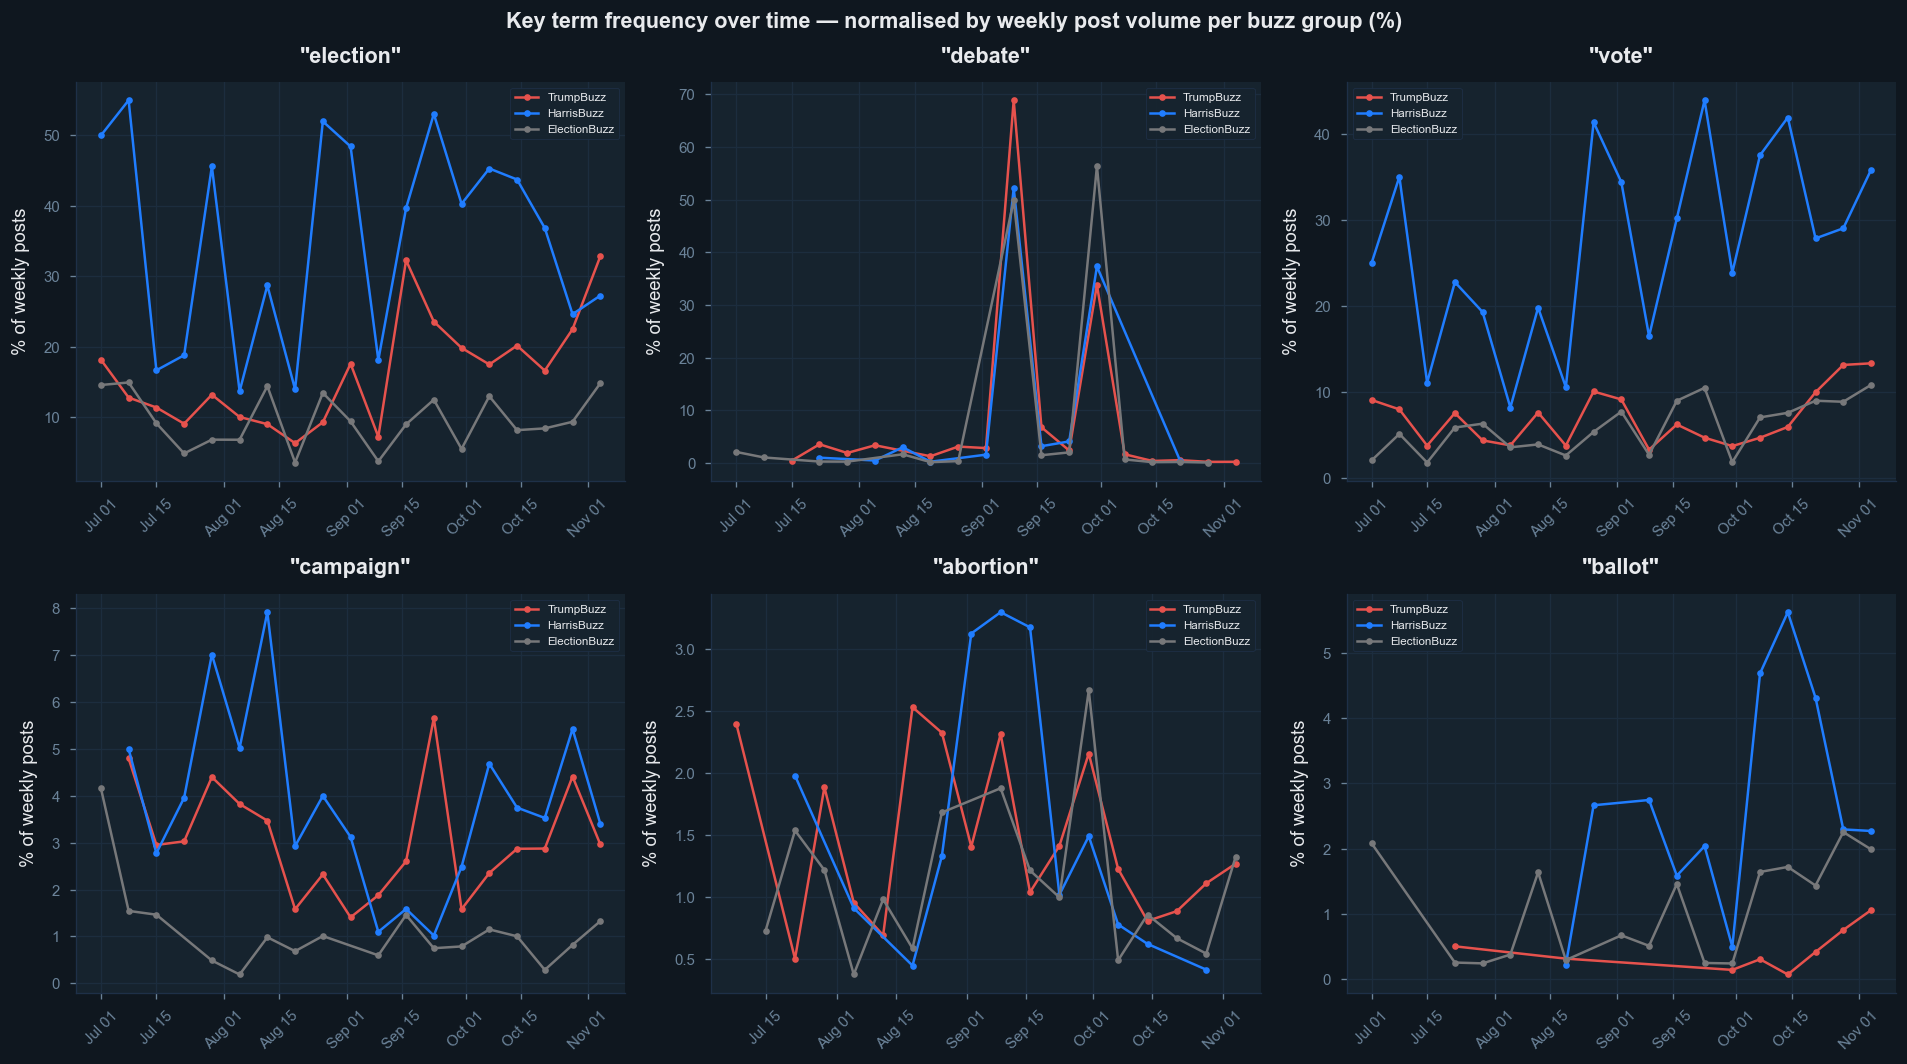

In [186]:
import matplotlib.dates as mdates
from house_style import *
apply_style()

TRACK_TERMS = [
    'debate', 'poll', 'abortion', 'immigration', 'economy',
    'campaign', 'vote', 'election', 'swing', 'battleground',
    'conviction', 'assassination', 'concede', 'ballot', 'tariff'
]

# ── Weekly totals per buzz group ──────────────────────────────────────────────
df_clean['week'] = pd.to_datetime(df_clean['date']).dt.to_period('W').dt.start_time

weekly_totals = (
    df_clean.groupby(['week', 'buzz_group'])
    .size()
    .reset_index(name='total')
)

# ── Count term occurrences per week per buzz group ────────────────────────────
results = []
for term in TRACK_TERMS:
    mask   = df_clean['text_norm'].str.contains(r'\b' + term + r'\b', regex=True, na=False)
    weekly = df_clean[mask].groupby(['week', 'buzz_group']).size().reset_index(name='count')
    weekly = weekly.merge(weekly_totals, on=['week', 'buzz_group'])
    weekly['share'] = weekly['count'] / weekly['total']
    weekly['term']  = term
    results.append(weekly)

term_df   = pd.concat(results, ignore_index=True)
top_terms = term_df.groupby('term')['count'].sum().nlargest(6).index.tolist()

# ── Plot ──────────────────────────────────────────────────────────────────────
colors_line = {
    'TrumpBuzz':    REPUBLICAN,
    'HarrisBuzz':   DEMOCRAT,
    'ElectionBuzz': NEUTRAL,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(BG_DARK)

for ax, term in zip(axes.flat, top_terms):
    ax.set_facecolor(BG_PANEL)
    subset = term_df[term_df['term'] == term]

    for group, color in colors_line.items():
        data = subset[subset['buzz_group'] == group]
        if not data.empty:
            ax.plot(data['week'], data['share'] * 100,
                    color=color, marker='o', ms=3,
                    linewidth=1.5, label=group)

    ax.set_title(f'"{term}"', color=TEXT_PRIMARY, fontweight='bold')
    ax.set_ylabel('% of weekly posts', color=TEXT_PRIMARY)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=45, colors=TEXT_MUTED)
    ax.tick_params(axis='y', colors=TEXT_MUTED)
    ax.legend(fontsize=7)

plt.suptitle('Key term frequency over time — normalised by weekly post volume per buzz group (%)',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Wordclouds

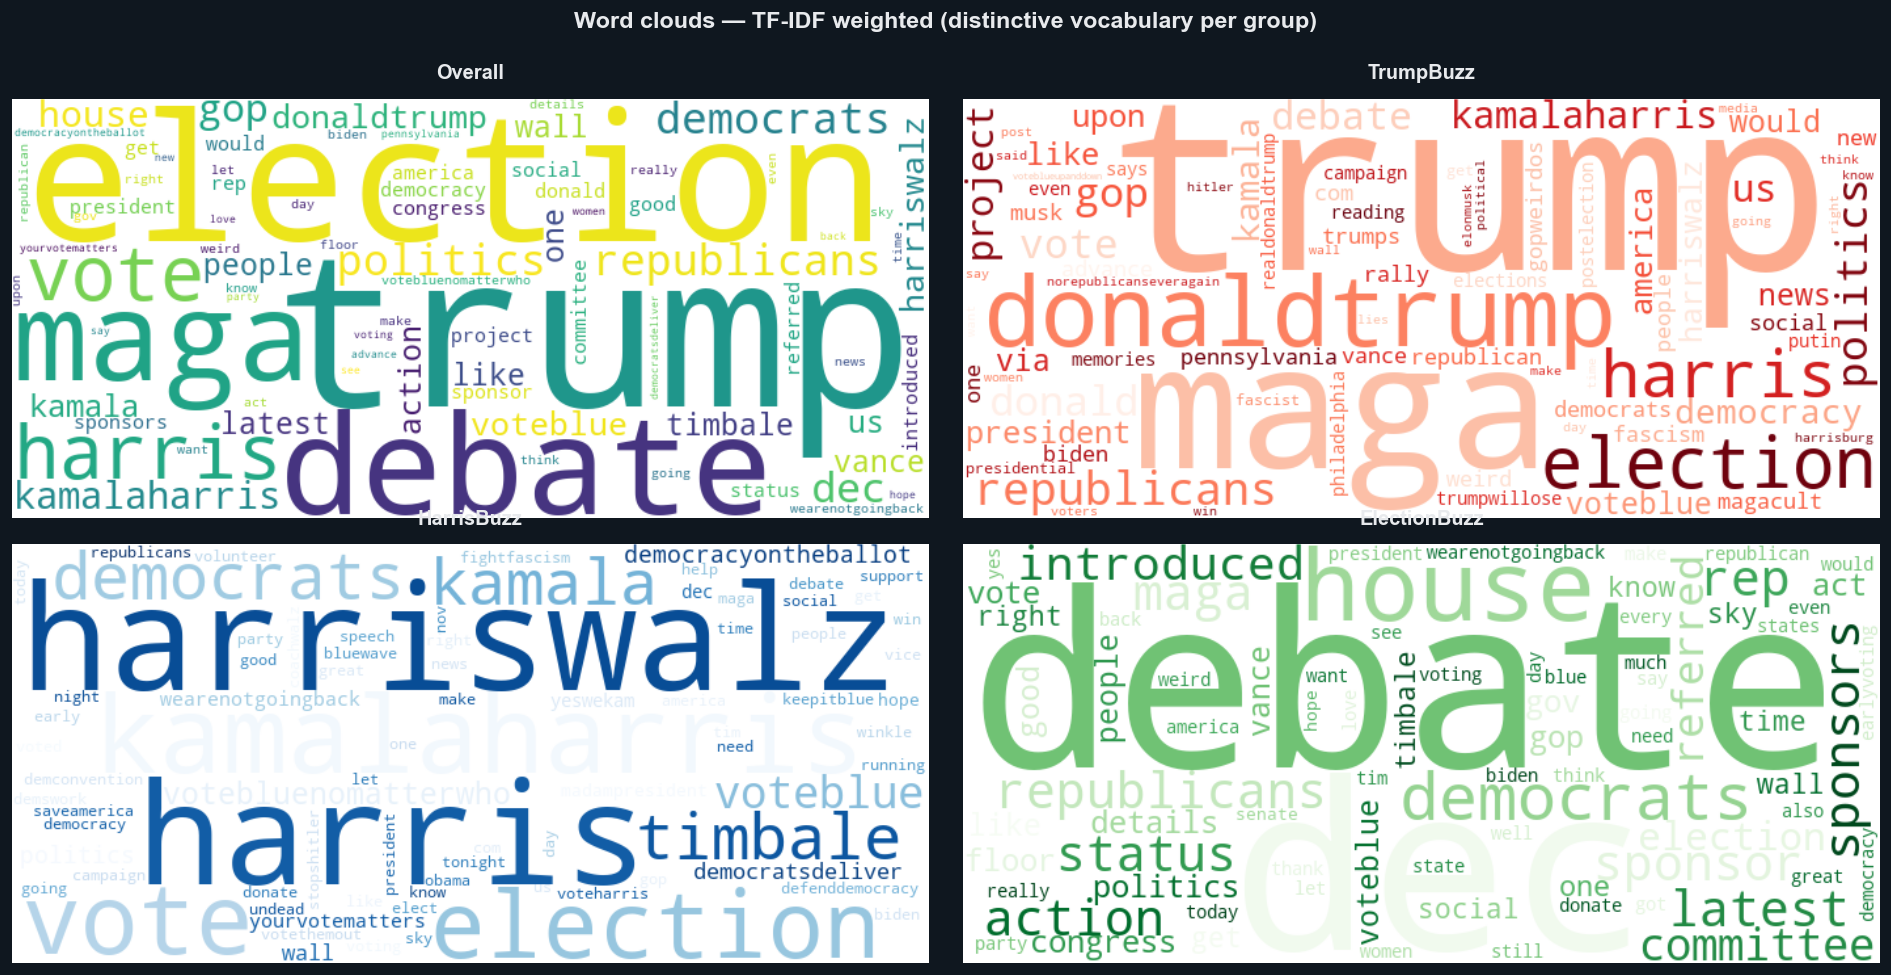

In [189]:
ALL_GROUPS = {
    'Overall':      df_clean,
    'TrumpBuzz':    df_clean[df_clean['buzz_group'] == 'TrumpBuzz'],
    'HarrisBuzz':   df_clean[df_clean['buzz_group'] == 'HarrisBuzz'],
    'ElectionBuzz': df_clean[df_clean['buzz_group'] == 'ElectionBuzz'],
}
colors_map = {
    'Overall':      'viridis',
    'TrumpBuzz':    'Reds',
    'HarrisBuzz':   'Blues',
    'ElectionBuzz': 'Greens',
}

def make_wc_tfidf(scores_dict, colormap):
    return WordCloud(width=700, height=320, background_color='white',
                     max_words=80, colormap=colormap,
                     relative_scaling=0.4).generate_from_frequencies(scores_dict)

def plot_wc_grid(wc_dict, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    for ax, (label, wc) in zip(axes.flat, wc_dict.items()):
        ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
        ax.set_title(label, fontsize=12, fontweight='bold')
    plt.suptitle(suptitle, fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

wc_tfidf = {}
for label, sub in ALL_GROUPS.items():
    mask        = df_clean.index.isin(sub.index)
    mean_scores = tfidf_matrix_2[mask].mean(axis=0).A1
    scores_dict = {feature_names_2[i]: mean_scores[i] for i in mean_scores.argsort()[::-1][:200]}
    wc_tfidf[label] = make_wc_tfidf(scores_dict, colors_map[label])

plot_wc_grid(wc_tfidf, 'Word clouds — TF-IDF weighted (distinctive vocabulary per group)')